# Explore and analyze the Financial PhraseBank / financial sentiment dataset

## Dataset: https://huggingface.co/datasets/takala/financial_phrasebank

### Step 1: Install & import libraries

In [1]:
# If needed
# pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Step 2: Load dataset

In [2]:
file_path = "data/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"  # change path

data = []
with open(file_path, "r", encoding="latin-1") as f:
    for line in f:
        text, label = line.strip().rsplit("@", 1)
        data.append([text, label])

df = pd.DataFrame(data, columns=["text", "sentiment"])
df.head()

,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


### Step 3: Basic dataset overview

In [4]:
print("Shape:", df.shape)
print("\nSentiment distribution:\n", df["sentiment"].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Shape: (2264, 2)

Sentiment distribution:
 sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Missing values:
 text         0
sentiment    0
dtype: int64


### Step 4: Visualize sentiment distribution

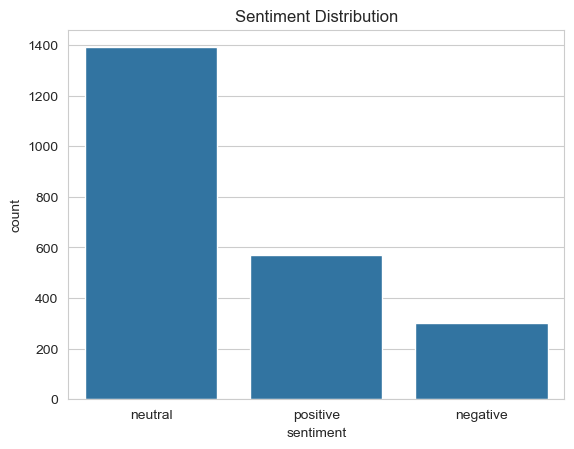

In [6]:
plt.figure()
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.show()

### Step 5: Basic text cleaning

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,text,sentiment,clean_text
0,"According to Gran , the company has no plans t...",neutral,according to gran the company has no plans to ...
1,"For the last quarter of 2010 , Componenta 's n...",positive,for the last quarter of componenta s net sales...
2,"In the third quarter of 2010 , net sales incre...",positive,in the third quarter of net sales increased by...
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,operating profit rose to eur mn from eur mn in...
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,operating profit totalled eur mn up from eur m...


### Step 6: Text length analysis

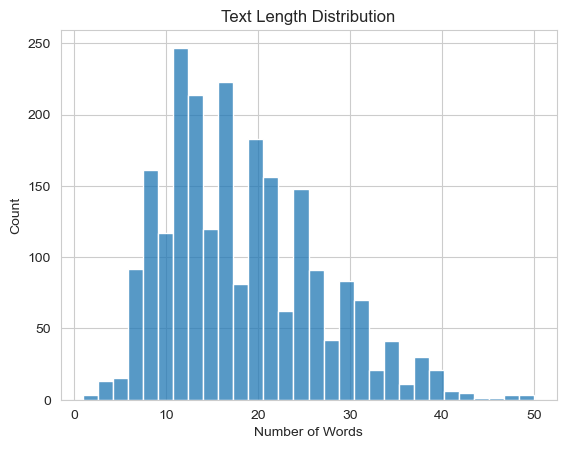

In [8]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(df["text_length"], bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

### Step 7: Most common words

In [9]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)
print(common_words)

[('the', 2730), ('of', 1525), ('in', 1384), ('and', 1166), ('to', 1081), ('eur', 954), ('a', 728), ('for', 541), ('from', 517), ('mn', 494), ('s', 461), ('is', 416), ('company', 349), ('will', 346), ('profit', 322), ('by', 303), ('net', 292), ('as', 274), ('on', 272), ('million', 267)]


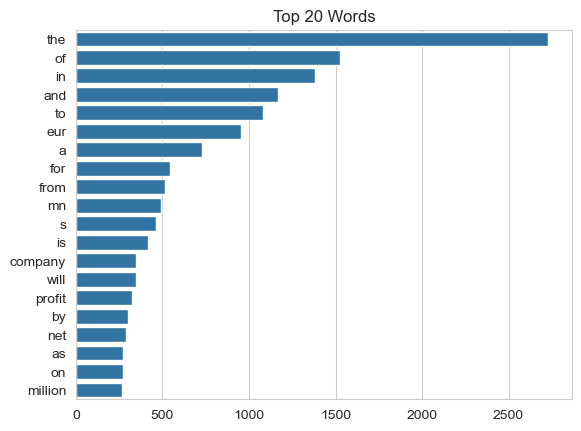

In [10]:
words, counts = zip(*common_words)

plt.figure()
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Words")
plt.show()

### Step 8: Sentiment-wise word analysis

In [11]:
positive_words = " ".join(df[df["sentiment"]=="positive"]["clean_text"]).split()
negative_words = " ".join(df[df["sentiment"]=="negative"]["clean_text"]).split()

print("Top positive words:", Counter(positive_words).most_common(10))
print("Top negative words:", Counter(negative_words).most_common(10))

Top positive words: [('the', 581), ('eur', 500), ('in', 442), ('to', 425), ('of', 361), ('from', 282), ('mn', 238), ('a', 209), ('and', 203), ('profit', 172)]
Top negative words: [('the', 339), ('eur', 298), ('in', 267), ('of', 256), ('to', 205), ('mn', 196), ('from', 147), ('a', 140), ('profit', 122), ('net', 84)]


### Step 9: Encode labels (for ML later)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


### Step 10: Train-test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42
)

# Baseline Model: TF-IDF + Logistic Regression

### 1. Import ML libraries

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. Convert text → TF-IDF features

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,      # limit vocab size
    ngram_range=(1, 2),     # unigrams + bigrams (important for finance phrases)
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (1811, 5000)


### 3. Train Logistic Regression

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4. Predictions

In [17]:
y_pred = model.predict(X_test_tfidf)

### 5. Evaluate model

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8410596026490066

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.55      0.66        56
           1       0.85      0.97      0.91       276
           2       0.82      0.69      0.75       121

    accuracy                           0.84       453
   macro avg       0.83      0.74      0.77       453
weighted avg       0.84      0.84      0.83       453



### 6. Confusion Matrix

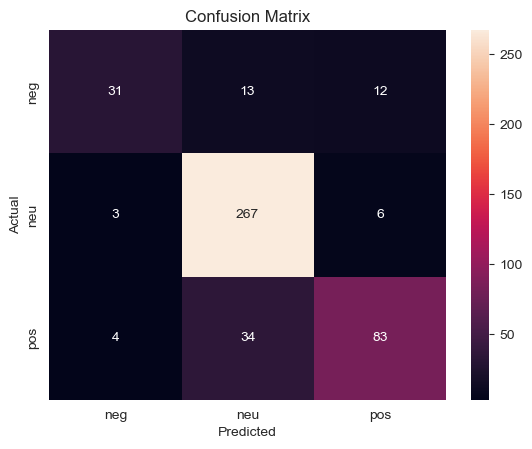

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["neg", "neu", "pos"],
            yticklabels=["neg", "neu", "pos"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 7. Inspect important words

In [20]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_

# For each class
for i, label in enumerate(le.classes_):
    print(f"\nTop words for {label}:")
    
    top_indices = coefficients[i].argsort()[-10:]
    print([feature_names[j] for j in top_indices])


Top words for negative:
['sales', 'eur', 'profit', 'dropped', 'margin', 'decreased eur', 'lower', 'half', 'fell', 'decreased']

Top words for neutral:
['production', 'disclosed', 'sales mln', 'mn operating', 'development', 'finland', 'sales eur', 'includes', 'approximately', 'value']

Top words for positive:
['improved', 'rose eur', 'awarded', 'said', 'percent', 'eur', 'grew', 'increase', 'increased', 'rose']
